# CS180 Proj1

### Test modules

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


print("Hello, World!")
print(np.__version__)
print(cv2.__version__)

Hello, World!
2.2.5
4.10.0


### Function import

In [4]:
# logic for the rest of the code goes here
'''
split_channels(image)

score_l2(img1, img2)
score_ncc(img1, img2)

align_single_scale(target, reference, search_range)

align_pyramid(target, reference)

colorize(image)

'''

import numpy as np

def split_channels(image):
    """
    Splits an image into its individual color channels.

    Parameters:
        image (numpy.ndarray): The input image to be split.

    Returns:
        tuple: A tuple containing the individual color channels.
    """
    # Assuming the image is in RGB format
    if len(image.shape) == 3 and image.shape[2] == 3:
        return image[:, :, 0], image[:, :, 1], image[:, :, 2]
    else:
        raise ValueError("Input image must be a 3-channel RGB image.")

def score_l2(img1, img2):
    """
    Computes the L2 score (Euclidean distance) between two images.

    Parameters:
        img1 (numpy.ndarray): The first input image.
        img2 (numpy.ndarray): The second input image.

    Returns:
        float: The L2 score between the two images.
    """
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)

    if img1.shape != img2.shape:
        raise ValueError("Input images must have the same dimensions.")
    
    return np.sqrt(np.sum((img1 - img2) ** 2))

def score_ncc(img1, img2):
    """
    Computes the Normalized Cross-Correlation (NCC) score between two images.

    Parameters:
        img1 (numpy.ndarray): The first input image.
        img2 (numpy.ndarray): The second input image.

    Returns:
        float: The NCC score between the two images.
    """
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)

    if img1.shape != img2.shape:
        raise ValueError("Input images must have the same dimensions.")
    
    img1_mean = np.mean(img1)
    img2_mean = np.mean(img2)
    denom1 = np.linalg.norm(img1 - img1_mean)
    denom2 = np.linalg.norm(img2 - img2_mean)
    if denom1 < 1e-8 or denom2 < 1e-8:
        return 0.0  # Avoid division by zero
        
    img1_normalized = (img1 - img1_mean) / denom1
    img2_normalized = (img2 - img2_mean) / denom2

    return np.sum(img1_normalized * img2_normalized)

def align_single_scale(target, reference, search_range=15, select="ncc", offset=(0, 0)):
    """
    Aligns the target image to the reference image using a single scale approach.

    Parameters:
        target (numpy.ndarray): The target image to be aligned.
        reference (numpy.ndarray): The reference image for alignment.
        search_range (int): The range of pixels to search for alignment.
        select (str): The metric to use for alignment ("ncc" or "l2").

    Returns:
        numpy.ndarray: The aligned target image.
    """
    # Placeholder for alignment logic
    
    border = search_range
    offset_x, offset_y = offset[0], offset[1]
    
    if select not in ["ncc", "l2"]:
        raise ValueError("Invalid selection for alignment metric. Choose 'ncc' or 'l2'.")

    best_dx_ncc, best_dy_ncc = 0, 0
    best_dx_l2, best_dy_l2 = 0, 0

    if select == "ncc":
        best_score_ncc = float('-inf')
        # Get best alignment using ncc score
        for i_x in range(-search_range, search_range + 1):
            for i_y in range(-search_range, search_range + 1):
                # Shift the target image
                shifted_target = np.roll(target, shift=(i_y + offset_y, i_x + offset_x), axis=(0, 1))
                # Compute the NCC score
                score = score_ncc(
                    shifted_target[border:-border, border:-border], 
                    reference[border:-border, border:-border]
                    )
                if score > best_score_ncc:
                    best_score_ncc = score
                    best_dx_ncc, best_dy_ncc = i_x, i_y
        aligned_ncc = np.roll(target, shift=(best_dy_ncc, best_dx_ncc), axis=(0, 1))
        return aligned_ncc, best_dx_ncc, best_dy_ncc, best_score_ncc

    else:
    # get best alignment using L2 score
        best_score_l2 = float('inf')
        for i_x in range(-search_range, search_range + 1):
            for i_y in range(-search_range, search_range + 1):
                # Shift the target image
                shifted_target = np.roll(target, shift=(i_y + offset_y, i_x + offset_x), axis=(0, 1))
                # Compute the L2 score
                score = score_l2(
                    shifted_target[border:-border, border:-border], 
                    reference[border:-border, border:-border]
                    )
                if score < best_score_l2:
                    best_score_l2 = score
                    best_dx_l2, best_dy_l2 = i_x, i_y

        aligned_l2 = np.roll(target, shift=(best_dy_l2, best_dx_l2), axis=(0, 1))
        return aligned_l2, best_dx_l2, best_dy_l2, best_score_l2
    

def colorize(aligned_red, aligned_green, b_cropped):
    """
    Colorizes a grayscale image.

    Parameters:
        b (numpy.ndarray): The blue channel image.
        g (numpy.ndarray): The green channel image.
        r (numpy.ndarray): The red channel image.

    Returns:
        numpy.ndarray: The colorized image.
    """

    color_img = np.dstack([
        aligned_red,
        aligned_green,
        b_cropped
    ])

    return color_img


## Data Input ## 

In [251]:
# input images data in sequence
import cv2
from pathlib import Path

# data_dir = Path("../CS180_fa2026_proj1_data")
data_dir = Path("test_images")

'''
idx in [0, 7, 12] are jpg; using single scale alignment for these images, and pyramid alignment for the rest of the images.

'''
IDX = 6
idx = IDX 

image_paths = [
    p for p in data_dir.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".tif", ".tiff"]
]
output_paths = [
    Path("test_results") / f"{img_path.stem}_{img_path.suffix[1:]}.jpg"
    for img_path in image_paths
]

print("Image paths:", image_paths)
print("Output paths:", output_paths)

# Save AFTER adding annotations
output_dir = Path("test_results")
output_dir.mkdir(parents=True, exist_ok=True)

for img_path in image_paths:
    img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)

    if img is None:
        continue

    # print("File:", img_path.name)
    # print("Shape:", img.shape)
    # print("Type:", img.dtype)

output_path = output_paths[IDX]





Image paths: [WindowsPath('test_images/test1.jpg'), WindowsPath('test_images/test1.tif'), WindowsPath('test_images/test2.jpg'), WindowsPath('test_images/test2.tif'), WindowsPath('test_images/test3.jpg'), WindowsPath('test_images/test3.tif'), WindowsPath('test_images/test4.jpg'), WindowsPath('test_images/test4.tif')]
Output paths: [WindowsPath('test_results/test1_jpg.jpg'), WindowsPath('test_results/test1_tif.jpg'), WindowsPath('test_results/test2_jpg.jpg'), WindowsPath('test_results/test2_tif.jpg'), WindowsPath('test_results/test3_jpg.jpg'), WindowsPath('test_results/test3_tif.jpg'), WindowsPath('test_results/test4_jpg.jpg'), WindowsPath('test_results/test4_tif.jpg')]


### Select an image to work with

In [252]:
img_path = image_paths[idx]
img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
img = img.astype(np.float32)

# normalize every input image to [0, 1]
img_min = img.min()
img_max = img.max()

if img_max > img_min:
    img = (img - img_min) / (img_max - img_min)

print("shape:", img.shape)
print("dtype:", img.dtype)
print("min:", img.min())
print("max:", img.max())
print("mean:", img.mean())

print("File:", img_path.name)
print("Shape:", img.shape)

shape: (640, 249)
dtype: float32
min: 0.0
max: 1.0
mean: 0.60814345
File: test4.jpg
Shape: (640, 249)


### Slice the images into R G B channels

In [253]:
# slice the image into its color channels,
height = int(np.floor(img.shape[0] / 3.0))

# separate color channels
b = img[:height]
g = img[height: 2*height]
r = img[2*height: 3*height]

WIDTH = b.shape[1]
HEIGHT = b.shape[0]
CROP_X = int(WIDTH * 0.10)  # number of pixels to crop from each side
CROP_Y = int(HEIGHT * 0.10)  # number of pixels to crop from each side


print("Blue channel shape:", b.shape, "Green channel shape:", g.shape, "Red channel shape:", r.shape)

# crop the image to eliminate black borders
# and also divide by 255 to normalize the pixel values to [0, 1]
b_cropped = b[CROP_Y:-CROP_Y, CROP_X:-CROP_X]
g_cropped = g[CROP_Y:-CROP_Y, CROP_X:-CROP_X]
r_cropped = r[CROP_Y:-CROP_Y, CROP_X:-CROP_X]



Blue channel shape: (213, 249) Green channel shape: (213, 249) Red channel shape: (213, 249)


### Show the sliced b\g\r images

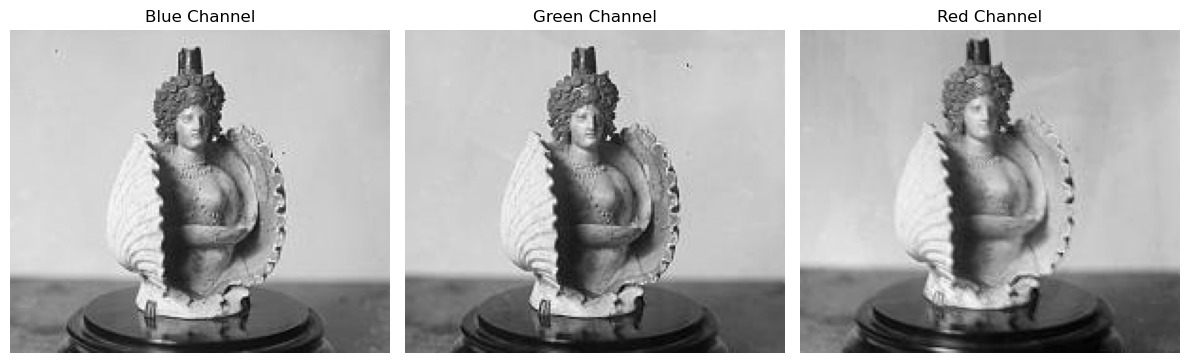

Blue channel shape: (171, 201) Green channel shape: (171, 201) Red channel shape: (171, 201)


In [254]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(b_cropped, cmap='gray')
axes[0].set_title('Blue Channel')
axes[0].axis('off')

axes[1].imshow(g_cropped, cmap='gray')
axes[1].set_title('Green Channel')
axes[1].axis('off')

axes[2].imshow(r_cropped, cmap='gray')
axes[2].set_title('Red Channel')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print ("Blue channel shape:", b_cropped.shape, "Green channel shape:", g_cropped.shape, "Red channel shape:", r_cropped.shape)

## Single-scale Alignment 

### Use L2 Score

Green channel aligned to Blue channel with L2 score: dx=1, dy=0, score=11.447547912597656
Red channel aligned to Blue channel with L2 score: dx=1, dy=5, score=11.928603172302246


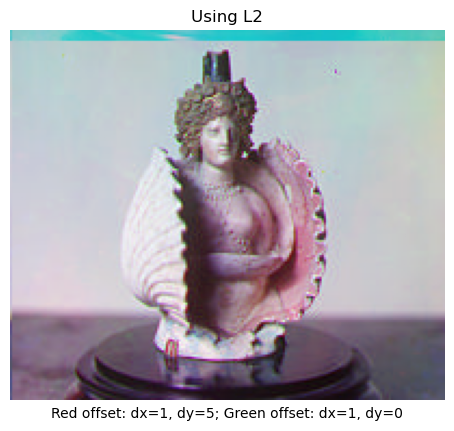

In [255]:
# Set Blue channel as the reference channel
RANGE = 15
# 1. Align the Green channel to the Blue channel using L2 score
aligned_green_l2, dx_g_l2, dy_g_l2, score_g_l2 = align_single_scale(g_cropped, b_cropped, search_range=RANGE, select="l2")
print(f"Green channel aligned to Blue channel with L2 score: dx={dx_g_l2}, dy={dy_g_l2}, score={score_g_l2}")

# 2. Align the Red channel to the Blue channel using L2 score
aligned_red_l2, dx_r_l2, dy_r_l2, score_r_l2 = align_single_scale(r_cropped, b_cropped, search_range=RANGE, select="l2")
print(f"Red channel aligned to Blue channel with L2 score: dx={dx_r_l2}, dy={dy_r_l2}, score={score_r_l2}")

# 3. Stack the aligned channels to form the final color image
color_img_l2 = colorize(aligned_red_l2, aligned_green_l2, b_cropped)

# 4. Show the final color image
plt.title(f"Using L2")
plt.imshow(color_img_l2)
plt.axis("off")
plt.gca().annotate(f"Red offset: dx={dx_r_l2}, dy={dy_r_l2}; Green offset: dx={dx_g_l2}, dy={dy_g_l2}", xy=(0.5,-0.05), xycoords='axes fraction', ha='center')
plt.show()

### Use NCC score ### 

Green channel aligned to Blue channel with NCC score: dx=1, dy=0, score=0.9573836922645569
Red channel aligned to Blue channel with NCC score: dx=1, dy=5, score=0.9418500661849976


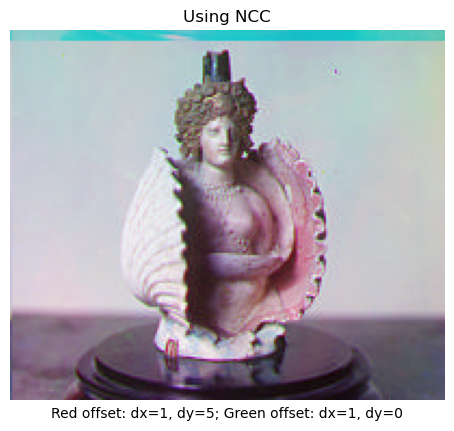

In [256]:
# Set Blue channel as the reference channel
RANGE = 15
# 1. Align the Green channel to the Blue channel using NCC score
aligned_green_ncc, dx_g_ncc, dy_g_ncc, score_g_ncc = align_single_scale(g_cropped, b_cropped, search_range=RANGE, select="ncc")
print(f"Green channel aligned to Blue channel with NCC score: dx={dx_g_ncc}, dy={dy_g_ncc}, score={score_g_ncc}")

# 2. Align the Red channel to the Blue channel using NCC score
aligned_red_ncc, dx_r_ncc, dy_r_ncc, score_r_ncc = align_single_scale(r_cropped, b_cropped, search_range=RANGE, select="ncc")
print(f"Red channel aligned to Blue channel with NCC score: dx={dx_r_ncc}, dy={dy_r_ncc}, score={score_r_ncc}")

# 3. Stack the aligned channels to form the final color image
color_img_ncc = colorize(aligned_red_ncc, aligned_green_ncc, b_cropped)

# 4. Show the final color image
plt.title(f"Using NCC")
plt.imshow(color_img_ncc)
plt.axis("off")
plt.gca().annotate(f"Red offset: dx={dx_r_ncc}, dy={dy_r_ncc}; Green offset: dx={dx_g_ncc}, dy={dy_g_ncc}", xy=(0.5,-0.05), xycoords='axes fraction', ha='center')
plt.show()

### Combine and Save the L2 result && the NCC result


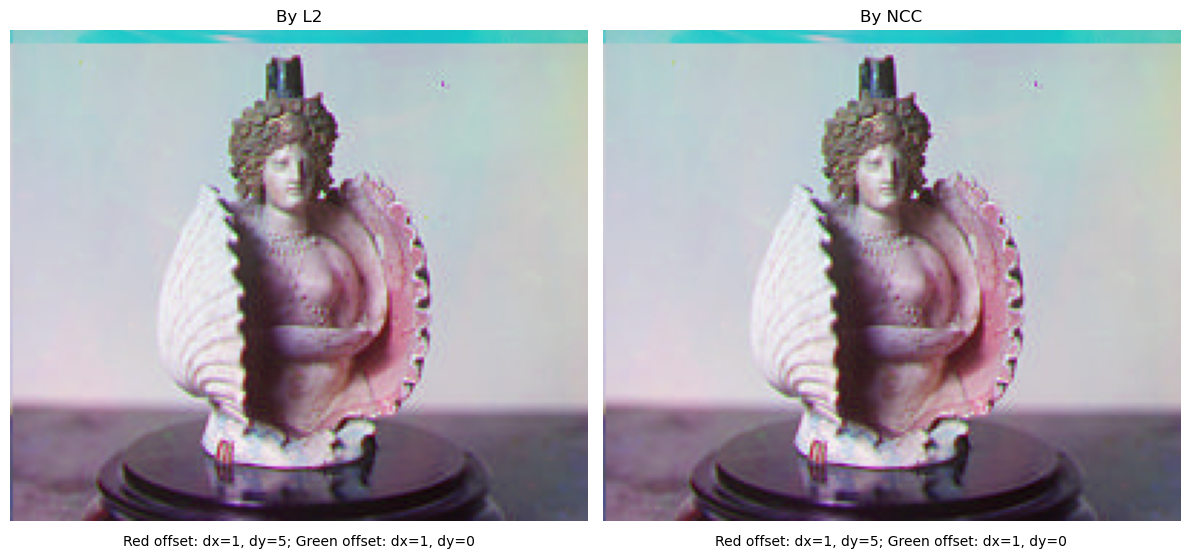

Saved: test_results\test4_jpg.jpg


In [257]:
import matplotlib.pyplot as plt
from pathlib import Path

combined_img, axes = plt.subplots(1, 2, figsize=(12, 6))

# L2
axes[0].imshow(color_img_l2)
axes[0].set_title('By L2')
axes[0].axis('off')

axes[0].annotate(
    f"Red offset: dx={dx_r_l2}, dy={dy_r_l2}; "
    f"Green offset: dx={dx_g_l2}, dy={dy_g_l2}",
    xy=(0.5, -0.05),
    xycoords='axes fraction',
    ha='center'
)

# NCC
axes[1].imshow(color_img_ncc)
axes[1].set_title('By NCC')
axes[1].axis('off')

axes[1].annotate(
    f"Red offset: dx={dx_r_ncc}, dy={dy_r_ncc}; "
    f"Green offset: dx={dx_g_ncc}, dy={dy_g_ncc}",
    xy=(0.5, -0.05),
    xycoords='axes fraction',
    ha='center'
)

plt.tight_layout()

combined_img.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_path)

## Coarse-to-fine Pyramid Speedup

### Resize the images

In [249]:
def resize(image, scale=2):
    small = cv2.resize(
        image,
        (image.shape[1] // scale, image.shape[0] // scale),
        interpolation=cv2.INTER_AREA
    )
    # print(f"Resized image from {image.shape} to {small.shape} with scale factor {scale}.")
    return small


def align_pyramid(b, g, r, div=16): 
    """
    Aligns the target image to the reference image using a multi-scale pyramid approach.

    Parameters:
        b (numpy.ndarray): The blue channel image.
        g (numpy.ndarray): The green channel image.
        r (numpy.ndarray): The red channel image.
        div (int): The initial scale factor for the pyramid.
    """
    first = True
    # iteratively resize the image from high resolution to low resolution, and then align the images at each scale

    offset_x_red = 0
    offset_y_red = 0
    offset_x_green = 0
    offset_y_green = 0
    
    center_r = [0, 0] # in original image coordinates, the center of the red channel
    center_g = [0, 0] # in original image coordinates, the center of the green channel

    while div >= 1:
        # Resize the images
        b_resized = resize(b, scale=div)
        g_resized = resize(g, scale=div)
        r_resized = resize(r, scale=div)
        
        # Update offsets for next iteration
        offset_x_red *= 2
        offset_y_red *= 2
        offset_x_green *= 2
        offset_y_green *= 2

        # Align the Green channel to the Blue channel using NCC score
        aligned_green_ncc, dx_g_ncc, dy_g_ncc, score_g_ncc = align_single_scale(
            g_resized, 
            b_resized, 
            search_range=max(div, 8),
            select="ncc",
            offset=(offset_x_green, offset_y_green)
            )
        print(f"\033[92mGreen\033[0m channel aligned to Blue channel with NCC score: dx={dx_g_ncc}, dy={dy_g_ncc}, scale={div}, score={score_g_ncc}")
        center_g[0] += dx_g_ncc * div
        center_g[1] += dy_g_ncc * div

        # Align the Red channel to the Blue channel using NCC score
        aligned_red_ncc, dx_r_ncc, dy_r_ncc, score_r_ncc = align_single_scale(
            r_resized, 
            b_resized, 
            search_range=max(div, 8),
            select="ncc",
            offset=(offset_x_red, offset_y_red)
            )
        print(f"\033[91mRed\033[0m channel aligned to Blue channel with NCC score: dx={dx_r_ncc}, dy={dy_r_ncc}, scale={div}, score={score_r_ncc}")
        center_r[0] += dx_r_ncc * div
        center_r[1] += dy_r_ncc * div

                # Update offsets for next iteration
        offset_x_red += dx_r_ncc
        offset_y_red += dy_r_ncc 
        offset_x_green += dx_g_ncc 
        offset_y_green += dy_g_ncc

        div //= 2  # Reduce the scale for the next iteration

        first = False
        
    
    print(f"center of red: {center_r}, center of green: {center_g}")
    return offset_x_red, offset_y_red, offset_x_green, offset_y_green



### Colorize the images and show

Green channel aligned to Blue channel with NCC score: dx=2, dy=1, scale=16, score=0.9784455895423889
Red channel aligned to Blue channel with NCC score: dx=3, dy=7, scale=16, score=0.9132657051086426
Green channel aligned to Blue channel with NCC score: dx=-1, dy=1, scale=8, score=0.9862810373306274
Red channel aligned to Blue channel with NCC score: dx=1, dy=-6, scale=8, score=0.8581362962722778
Green channel aligned to Blue channel with NCC score: dx=1, dy=-1, scale=4, score=0.9889318346977234
Red channel aligned to Blue channel with NCC score: dx=1, dy=-8, scale=4, score=0.8236804604530334
Green channel aligned to Blue channel with NCC score: dx=0, dy=-2, scale=2, score=0.9818421602249146
Red channel aligned to Blue channel with NCC score: dx=1, dy=-8, scale=2, score=0.8110655546188354
Green channel aligned to Blue channel with NCC score: dx=-1, dy=1, scale=1, score=0.9671839475631714
Red channel aligned to Blue channel with NCC score: dx=3, dy=-8, scale=1, score=0.8048579096794128


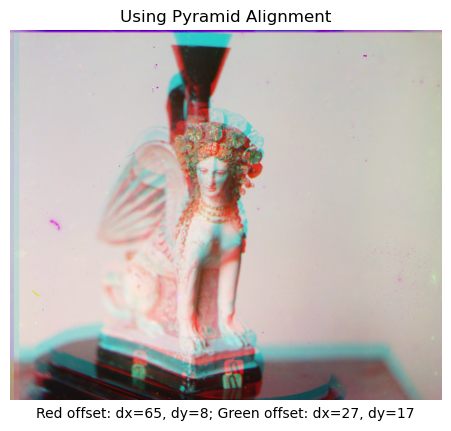

In [250]:

DIV = 16

offset_x_red, offset_y_red, offset_x_green, offset_y_green = align_pyramid(b_cropped, g_cropped, r_cropped, div=DIV)
aligned_green = np.roll(
        g_cropped,
        shift=(offset_y_green, offset_x_green),
        axis=(0, 1)
    )

aligned_red = np.roll(
    r_cropped,
    shift=(offset_y_red, offset_x_red),
    axis=(0, 1)
)

print(f"Final offsets: Red channel: dx={offset_x_red}, dy={offset_y_red}; Green channel: dx={offset_x_green}, dy={offset_y_green}")

pyramid_color_img = colorize(aligned_red, aligned_green, b_cropped)

plt.title(f"Using Pyramid Alignment")
plt.imshow(pyramid_color_img)
plt.axis("off")
plt.gca().annotate(f"Red offset: dx={offset_x_red}, dy={offset_y_red}; Green offset: dx={offset_x_green}, dy={offset_y_green}", xy=(0.5,-0.05), xycoords='axes fraction', ha='center')


plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)


print("Saved:", output_path)

plt.show()